[Material used to generate Fig.9]

Plot the exponents a_ns (for vGM) and a_sh (for vGM and BCB) as function of the shape parameter b, and fit them with simple expressions. The min and max values of the ratio q_approx / q_exact is ploted as function of the shape parameter b.

The analysis is carried out on the data generated with exp2.py.

In [1]:
# Standard imports
import pathlib

# Third party imports
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Internal imports

In [2]:
# set plot style
%matplotlib widget
plt.style.use('plot_style.txt')

# output path for figures 
output_path = pathlib.Path("/home/jonas/shared/Work/SSeep2026/Figures")

In [3]:
# load data
ns_vGM = pd.read_csv('../data/exp2_vGM/a_ns.csv', index_col=0)
sh_vGM = pd.read_csv('../data/exp2_vGM/a_sh.csv', index_col=0)
sh_BCB = pd.read_csv('../data/exp2_BCB/a_sh.csv', index_col=0)

# set colors
c_vGM = "#ce3d19ff"
c_BCB = "#dbcd06ff"
c_err = "#c472ebff"

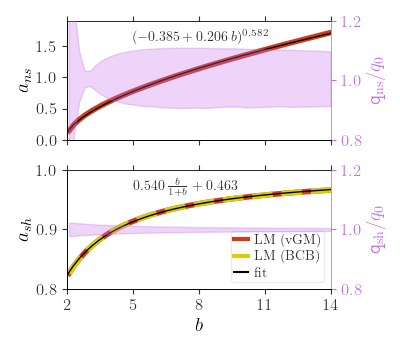

In [4]:
fig, axs = plt.subplots(2, 1, figsize=(4, 3.5))
for ax in axs:
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.tick_params(top=True, right=False)
    ax.set(xscale='linear', yscale='linear')
    ax.set_xlim(xmin=2, xmax=14)
ax0_tw = axs[0].twinx()
ax1_tw = axs[1].twinx()


# negligible to soft

# plot least-square minimization results
axs[0].plot(ns_vGM['b'], ns_vGM['a_ns'], ls='-', lw=4, c=c_vGM, zorder=1,
            label='vGM')

# fit and plot fit
fit = lambda b, c1, c2, c3: (c1 + c2 * b)**c3
p_ns, _ = curve_fit(fit, ns_vGM['b'], ns_vGM['a_ns'], p0=[1, 1, 1])
x = np.linspace(2, 16)
y = fit(x, *p_ns)
axs[0].plot(x, y, ls='-', c='k', lw=1, zorder=3)
axs[0].text(0.25, 0.92,
            f'$({p_ns[0]:.3f} + {p_ns[1]:.3f} \\: b)^{{{p_ns[2]:.3f}}}$',
            transform=axs[0].transAxes, va='top', ha='left')

# plot max and min relative errors
ax0_tw.fill_between(ns_vGM['b'], ns_vGM['res. min'], ns_vGM['res. max'],
                    ls='-', lw=1, ec=c_err, fc=c_err, alpha=0.3, zorder=1)




# soft to hard

# plot least-square minimization results
axs[1].plot(sh_vGM['b'], sh_vGM['a_sh'], ls='-', lw=4, c=c_vGM, zorder=1)
axs[1].plot(sh_BCB['b'], sh_BCB['a_sh'], ls='--', lw=4, c=c_BCB, zorder=2)

# fit and plot fit
fit = lambda b, c1, c2: c1 * b / (1 + b) + c2
p_sh, _ = curve_fit(fit, sh_vGM['b'], sh_vGM['a_sh'], p0=[1, 1])
x = np.linspace(2, 16)
y = fit(x, *p_sh)
axs[1].plot(x, y, ls='-', c='k', lw=1, zorder=3)
axs[1].text(0.25, 0.92,
            f'${p_sh[0]:.3f} \\, \\frac{{b}}{{1+b}} + {p_sh[1]:.3f}$',
            transform=axs[1].transAxes, va='top', ha='left')

# plot max and min relative errors
ax1_tw.fill_between(sh_vGM['b'], sh_vGM['res. min'], sh_vGM['res. max'],
                    ls='-', lw=1, ec=c_err, fc=c_err, alpha=0.3, zorder=0)



# layout
axs[0].set_ylim(ymin=0., ymax=1.9)
axs[0].set_yticks([0, 0.5, 1, 1.5])
axs[0].set_ylabel('$a_{ns}$', fontsize=14)
axs[0].set_xticks([2, 5, 8, 11, 14], labels=[])

axs[1].set_ylim(ymin=0.8, ymax=1.)
axs[1].set_yticks([0.8, 0.9, 1.0])
axs[1].set_xlabel('$b$', fontsize=14)
axs[1].set_ylabel('$a_{sh}$', fontsize=14)
axs[1].set_xticks([2, 5, 8, 11, 14])

ax0_tw.set_ylim(ymin=0.8, ymax=1.2)
ax0_tw.set_ylabel('$\\mathtt{q}_\\mathrm{ns} / q_0$', fontsize=14, color=c_err)
ax0_tw.tick_params(color=c_err, labelcolor=c_err)
axs[0].spines['right'].set_color(c_err)

ax1_tw.set_ylim(ymin=0.8, ymax=1.2)
ax1_tw.set_ylabel('$\\mathtt{q}_\\mathrm{sh} / q_0$', fontsize=14, color=c_err)
ax1_tw.tick_params(color=c_err, labelcolor=c_err)
axs[1].spines['right'].set_color(c_err)


legend = [Line2D([0], [0], ls='-', lw=3, color=c_vGM, label='LM (vGM)'),
          Line2D([0], [0], ls='-', lw=3, color=c_BCB, label='LM (BCB)'),
          Line2D([0], [0], ls='-', lw=1.5, color='k', label='fit')]
          
axs[1].legend(handles=legend, fontsize=10, columnspacing=0.6, handlelength=1,
           labelspacing=0.2, handletextpad=0.4,         
           loc='lower right', bbox_to_anchor=(1, 0))

plt.tight_layout()
#plt.savefig(output_path / f'transition_equations.pdf')